In [4]:
%pwd
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
from scripts.run_experiments import run_experiment
from scripts.experiment_utils import generate_experiments

In [ ]:

base_config = {
    # Experiment
    "experiment": "flower_scrunchy",
    "random_seed": 42,
    "logging": True,

    # Dataset
    "dataset_name": "flower_scrunchy",
    "batch_size": 64,
    "rotation": "random",
    "translation": None,
    "n_times": 10000,
    "radius": 2.0,
    "n_wiggles": 4,
    "geodesic_distortion_amp": 0.1,
    "embedding_dim": 10,
    "noise_var": 0.001,

    # Model
    'model_type': 'EuclideanVAE',
    "data_dim": 10,
    'latent_dim': 2,
    'sftbeta': 4.5,
    'device': "cpu",
    'encoder_widths': [50, 50, 50],
    'decoder_widths': [32, 32, 32],

    # Optimizer
    "learning_rate": 0.001,

    # Trainer
    'verbose': False,
    'num_epochs': 15,
    'log_interval': 100,
    'recon_loss': "MSE",
    'topo_loss': True,
    'dim_topo_loss': 0,  # Max feature dimension topological loss
    'alpha': 1.0,  # Weight for reconstruction loss
    'beta': 0.0,  # Weight for KL loss
    'gamma': 0.0,  # Weight for topological loss

    # Curvature computation
    "compute_true_curv": True,
    "compute_learned_curv": True,
    "compute_rec_curv": True,
    "quadric_dim": 1,
    "n_plot_points": 1000,
    "n_points_emp_curv": 800,
    "n_points_pullback_curv": 800, 
    "k": 110,

    # Persistent homology
    "persistent_homology": False,
    "n_points_pers_hom": 1000,
    "scale": False,
    "homology_dimensions": [0, 1]
}

param_grid = {
    "wiggling_dim": [4] * 14,
    "embedding_dim": [10] * 14,
    "alpha": [1] * 2 + [1, 1, 1, 0] * 3,
    "gamma": [0] * 2 + [1, 100, 1000, 1] * 3,
    "geodesic_distortion_amp": [0.5] * 14,
    "dim_topo_loss": [0] + [1] + [0] * 4 + [1] * 4 + [2] * 4,
}

# param_grid = {
#     "alpha": [1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0] * 3,
#     "gamma": [0.0, 1.0, 1.0, 100.0, 100.0, 1.0, 1.0] * 3,
#     "dim_topo_loss": ["_", 0, 1, 0, 1, 0, 1] * 3,
#     "geodesic_distortion_amp": [0.5] * 7 + [2.5] * 14,
#     "noise_var": [0.001] * 14 + [0.01] * 7,
#     "n_times": [10000] * 7 + [20000] * 14,
# }

all_configs = generate_experiments(base_config, param_grid)


----------------------------------------------------------------
Running exp00_flower_scrunchy. Description: alpha=1.0, gamma=0.0, geodesic_distortion_amp=0.5, noise_var=0.001, n_grid_points=800, n_times=10000
----------------------------------------------------------------


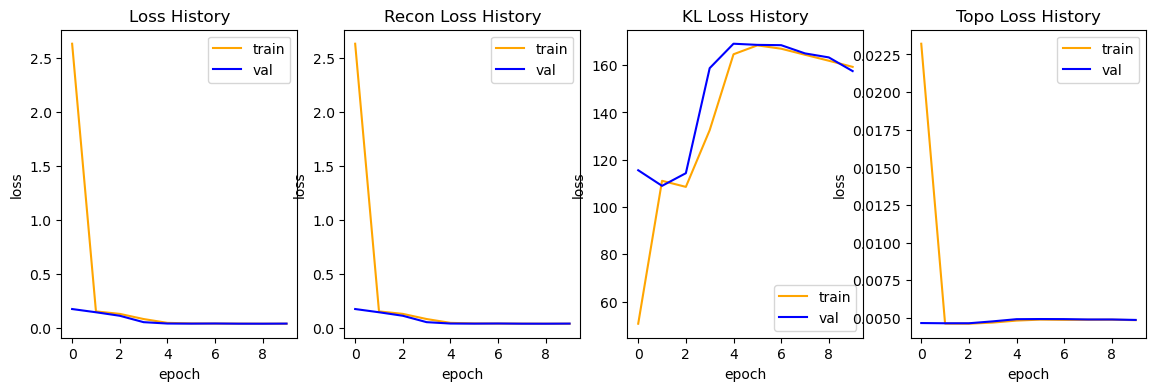

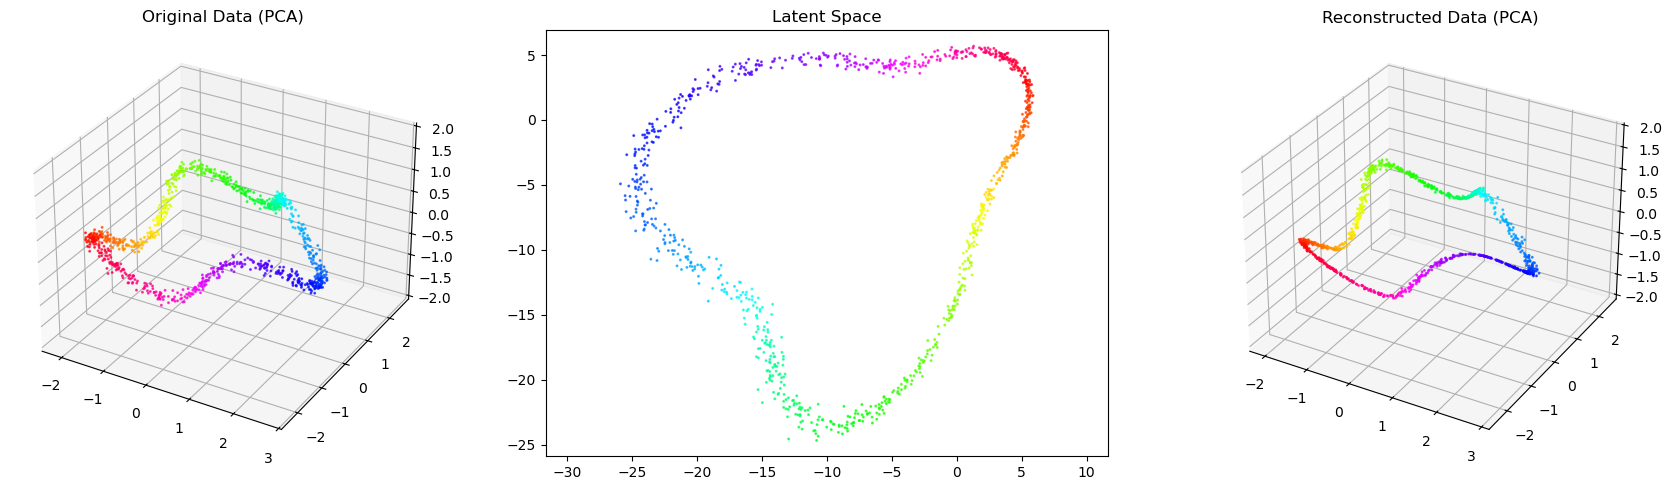

Computing persistence diagrams
Computing bottleneck distance
Computing betti curves


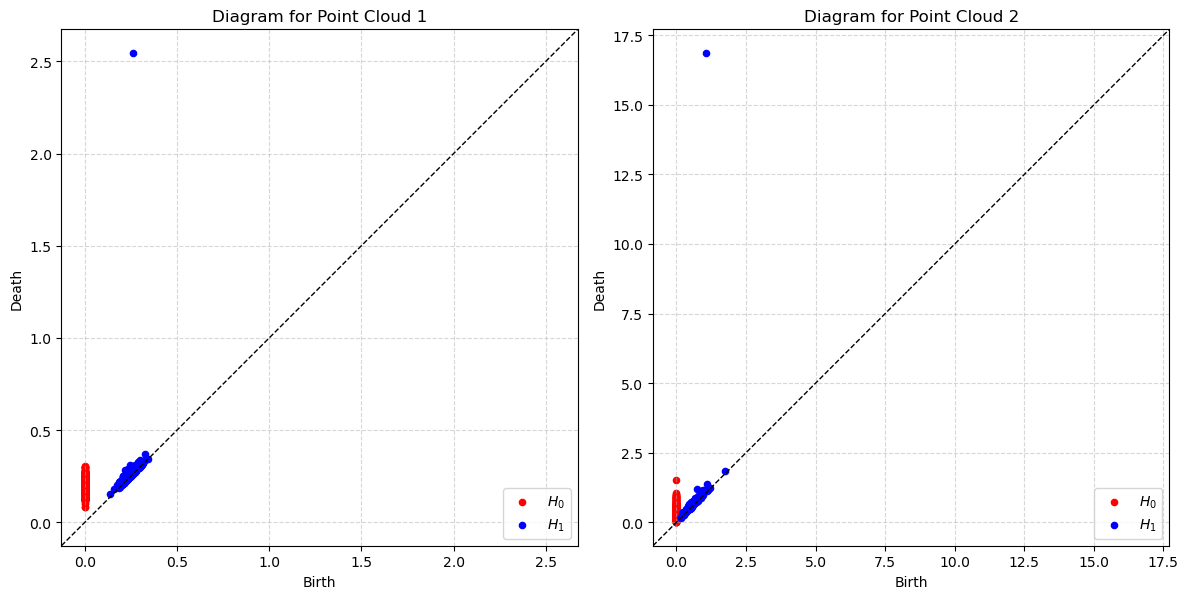

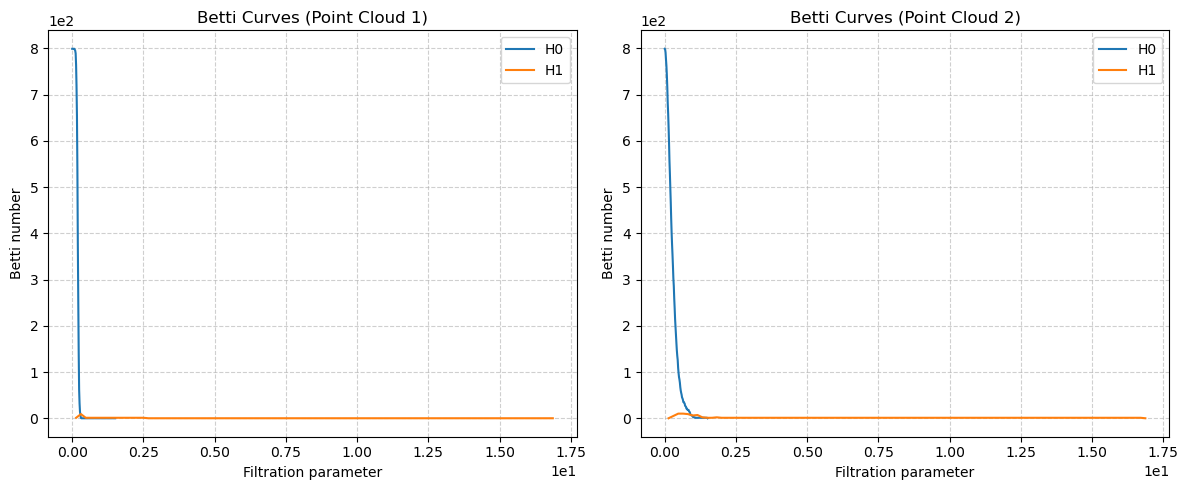

DISTANCES [[0.         8.0023086 ]
 [7.98082831 0.        ]]
----------------------------------------------------------------
Running exp01_flower_scrunchy. Description: alpha=1.0, gamma=1.0, dim_topo_loss=0, geodesic_distortion_amp=0.5, noise_var=0.001, n_grid_points=800, n_times=10000
----------------------------------------------------------------


KeyboardInterrupt: 

In [6]:
run_experiment(all_configs=all_configs)